In [ ]:
from google.colab import files
uploaded = files.upload()   # a button will appear — choose your CSV file

Saving car_price_prediction.csv to car_price_prediction.csv


In [ ]:
import pandas as pd

df = pd.read_csv('car_price_prediction.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
df.head()

Shape: (19237, 18)

Columns: ['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']

Data types:
 ID                    int64
Price                 int64
Levy                 object
Manufacturer         object
Model                object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume        object
Mileage              object
Cylinders           float64
Gear box type        object
Drive wheels         object
Doors                object
Wheel                object
Color                object
Airbags               int64
dtype: object


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [ ]:
df_clean = df.copy()

# Mileage: remove " km" and convert to number
df_clean['Mileage'] = df_clean['Mileage'].str.replace(' km', '', regex=False).astype(float)

# Engine volume: remove "Turbo" text if present, convert to number
df_clean['Engine volume'] = df_clean['Engine volume'].str.replace(' Turbo', '', regex=False).astype(float)

# Levy: replace '-' (missing) with 0, convert to number
df_clean['Levy'] = df_clean['Levy'].replace('-', 0).astype(float)

# Car age instead of production year (easier for the model to use)
df_clean['Car_Age'] = 2024 - df_clean['Prod. year']

# Select simple numeric features + target
features = ['Car_Age', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags', 'Levy']
target = 'Price'

df_model = df_clean[features + [target]].dropna()

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", df_model.shape[0])
print("\nFeature ranges:\n", df_model[features].describe())
print("\nTarget (Price) range:\n", df_model[target].describe())

Rows before cleaning: 19237
Rows after cleaning: 19237

Feature ranges:
             Car_Age  Engine volume       Mileage     Cylinders       Airbags  \
count  19237.000000   19237.000000  1.923700e+04  19237.000000  19237.000000   
mean      13.087176       2.307990  1.532236e+06      4.582991      6.582627   
std        5.668673       0.877805  4.840387e+07      1.199933      4.320168   
min        4.000000       0.000000  0.000000e+00      1.000000      0.000000   
25%        9.000000       1.800000  7.013900e+04      4.000000      4.000000   
50%       12.000000       2.000000  1.260000e+05      4.000000      6.000000   
75%       15.000000       2.500000  1.888880e+05      4.000000     12.000000   
max       85.000000      20.000000  2.147484e+09     16.000000     16.000000   

               Levy  
count  19237.000000  
mean     632.528669  
std      567.721688  
min        0.000000  
25%        0.000000  
50%      642.000000  
75%      917.000000  
max    11714.000000  

Target 

In [ ]:
# Keep only realistic values
df_model = df_model[
    (df_model['Mileage'] < 500000) &      # under 500,000 km
    (df_model['Price'] > 500) & (df_model['Price'] < 100000) &  # realistic price range
    (df_model['Car_Age'] < 30) &           # under 30 years old
    (df_model['Engine volume'] < 6)        # under 6 litres
]

print("Rows after outlier removal:", df_model.shape[0])
print("\nFeature ranges:\n", df_model[features].describe())
print("\nTarget (Price) range:\n", df_model[target].describe())

Rows after outlier removal: 17015

Feature ranges:
             Car_Age  Engine volume        Mileage     Cylinders       Airbags  \
count  17015.000000   17015.000000   17015.000000  17015.000000  17015.000000   
mean      12.929709       2.276779  133934.251131      4.546341      6.536233   
std        5.104756       0.820833   87966.611580      1.163924      4.187263   
min        4.000000       0.000000       0.000000      1.000000      0.000000   
25%        9.000000       1.800000   70298.000000      4.000000      4.000000   
50%       12.000000       2.000000  124000.000000      4.000000      6.000000   
75%       15.000000       2.500000  180973.000000      4.000000     12.000000   
max       29.000000       5.900000  498815.000000     16.000000     16.000000   

               Levy  
count  17015.000000  
mean     623.972612  
std      554.485828  
min        0.000000  
25%        0.000000  
50%      642.000000  
75%      900.000000  
max    11714.000000  

Target (Price) rang

### **prepare X, y and normalize. Paste and run:**

In [ ]:
X = df_model[features].values
y = df_model[target].values.reshape(-1, 1)

# Normalize features (min-max scaling) - important for gradient descent
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# Normalize target too (helps SGD converge smoothly)
y_min = y.min()
y_max = y.max()
y_norm = (y - y_min) / (y_max - y_min)

print("X_norm shape:", X_norm.shape)
print("y_norm shape:", y_norm.shape)
print("\nFirst 5 rows of X_norm:\n", X_norm[:5])
print("\nFirst 5 y_norm:\n", y_norm[:5].flatten())

X_norm shape: (17015, 6)
y_norm shape: (17015, 1)

First 5 rows of X_norm:
 [[0.4        0.59322034 0.37289376 0.33333333 0.75       0.11942974]
 [0.36       0.50847458 0.38491224 0.33333333 0.5        0.08690456]
 [0.56       0.22033898 0.40095025 0.2        0.125      0.        ]
 [0.36       0.42372881 0.3387348  0.2        0.         0.07358716]
 [0.24       0.22033898 0.18423865 0.2        0.25       0.0380741 ]]

First 5 y_norm:
 [0.12922308 0.16252237 0.08006795 0.03092294 0.11302343]


In [ ]:
import numpy as np
np.random.seed(42)
n = X_norm.shape[0]
idx = np.random.permutation(n)
split = int(0.8 * n)

X_train, y_train = X_norm[idx[:split]], y_norm[idx[:split]]
X_test, y_test = X_norm[idx[split:]], y_norm[idx[split:]]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 13612
Testing samples: 3403


Initialize weights and write the SGD training loop. This is a linear regression model (price = X·w + b), trained with Stochastic Gradient Descent

In [ ]:
def initialize_weights(n_features):
    np.random.seed(1)
    w = np.random.randn(n_features, 1) * 0.01
    b = 0.0
    return w, b

def predict(X, w, b):
    return X.dot(w) + b

def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def train_sgd(X, y, epochs, lr):
    n_samples, n_features = X.shape
    w, b = initialize_weights(n_features)
    loss_history = []

    for epoch in range(epochs):
        # shuffle data every epoch (key part of SGD)
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n_samples):
            xi = X_shuffled[i:i+1]     # one single row
            yi = y_shuffled[i:i+1]

            y_pred = predict(xi, w, b)
            error = y_pred - yi

            # gradients for THIS one sample
            dw = xi.T.dot(error)
            db = np.sum(error)

            # update weights immediately (this is what makes it "stochastic")
            w -= lr * dw
            b -= lr * db

        # after each epoch, record loss on full training set
        full_pred = predict(X, w, b)
        loss = compute_loss(y, full_pred)
        loss_history.append(loss)

    return w, b, loss_history

# quick test run
w, b, loss_history = train_sgd(X_train, y_train, epochs=10, lr=0.1)
print("Loss per epoch:", loss_history)

Loss per epoch: [np.float64(0.019347986798685764), np.float64(0.01950511367494979), np.float64(0.01912118258733004), np.float64(0.01848837971550418), np.float64(0.019762756336119583), np.float64(0.019666653719639462), np.float64(0.018977614225014098), np.float64(0.020893061590689398), np.float64(0.01940748510296617), np.float64(0.018862589790911502)]


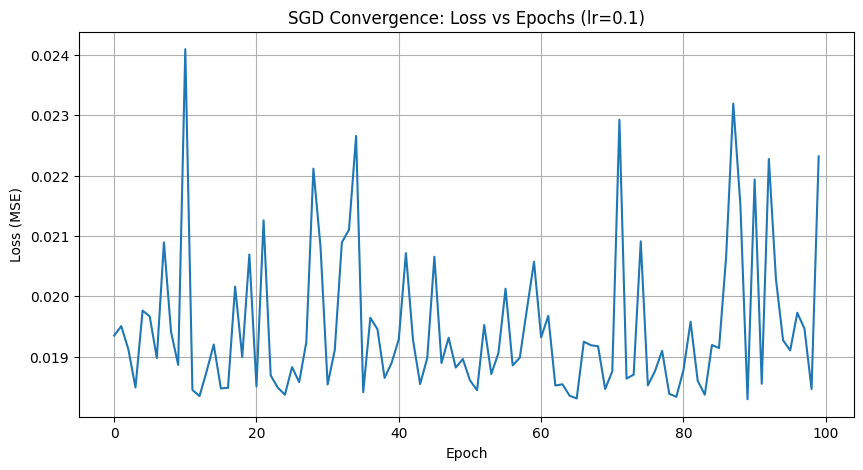

Final loss after 100 epochs: 0.022318690463360533


In [ ]:
import matplotlib.pyplot as plt

w, b, loss_history_100 = train_sgd(X_train, y_train, epochs=100, lr=0.1)

plt.figure(figsize=(10, 5))
plt.plot(loss_history_100)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("SGD Convergence: Loss vs Epochs (lr=0.1)")
plt.grid(True)
plt.show()

print("Final loss after 100 epochs:", loss_history_100[-1])

lr=0.1 | Final loss: 0.022319
lr=0.001 | Final loss: 0.018297
lr=0.0001 | Final loss: 0.018765


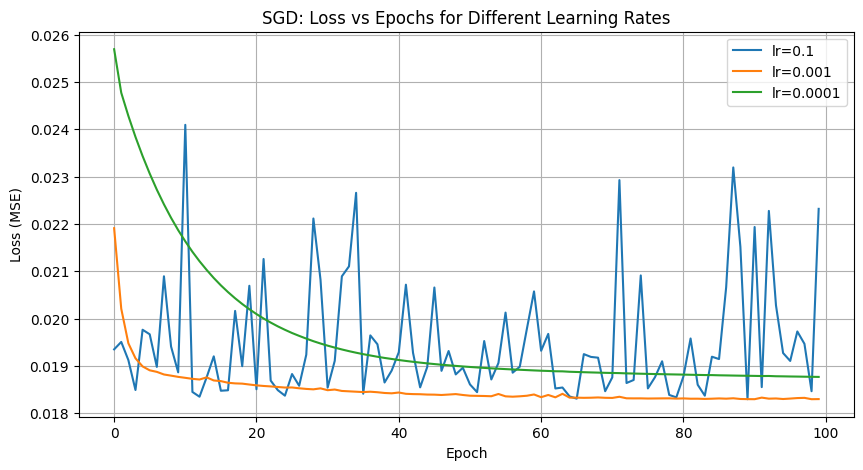

In [ ]:
results = {}

for lr in [0.1, 0.001, 0.0001]:
    w, b, history = train_sgd(X_train, y_train, epochs=100, lr=lr)
    results[lr] = history
    print(f"lr={lr} | Final loss: {history[-1]:.6f}")

plt.figure(figsize=(10, 5))
for lr, history in results.items():
    plt.plot(history, label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("SGD: Loss vs Epochs for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()